# 📱 Telco Customer Churn Prediction
**End-to-End Machine Learning Solution & API Service**

---

### Executive Summary & Business Problem
In the telecommunications industry, customer churn (customers switching to competitors) is a major revenue threat. Acquiring a new customer can cost 5x to 25x more than retaining an existing one. 

This project delivers a machine learning solution to proactively identify high-risk churn customers. By leveraging historical customer demographics, service subscriptions, contract types, and billing history from the **IBM Telco Customer Churn Dataset**, we train and evaluate multiple **Decision Tree Classifiers**, conduct feature engineering, analyze feature importances, and package the solution into a production-ready **FastAPI REST API**.

---
## Project Table of Contents
1. **Data Understanding & Preparation**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Engineering**
4. **Model Development & Experimentation**
5. **Model Evaluation & Business Analysis**
6. **Model Interpretation**
7. **Model Serialization & Saved Pipeline Verification**
8. **REST API Architecture & Sample Inference**


## 1. Data Understanding & Preparation

We load the dataset, check data types, handle missing values (specifically in `TotalCharges`), verify duplicate records, identify numerical and categorical features, and split the data into training (70%) and testing (30%) sets using `random_state=42` to avoid data leakage.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Plot settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11

# Load Dataset
DATA_PATH = os.path.join("..", "data", "TelcoCustomerChurn.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Data Types & Structure Check
print("--- Data Info ---")
df.info()

# Missing Value Audit
print("\n--- Missing Values Per Column ---")
print(df.isna().sum())

# TotalCharges conversion (handles whitespace strings " ")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_total_charges = df['TotalCharges'].isna().sum()
print(f"\nFound {blank_total_charges} blank entries in TotalCharges. Imputing with 0.0 (tenure=0).")
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Duplicate Check
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")

# Target Variable Distribution
print("\n--- Target Class Distribution (Churn) ---")
print(df['Churn'].value_counts(normalize=True).map('{:.2%}'.format))


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

## 2. Exploratory Data Analysis (EDA)

We create 5 meaningful visualizations to uncover patterns associated with customer churn.

### Visualization 1: Churn Distribution


C:\Users\kamalkumar\AppData\Local\Temp\ipykernel_33376\1668364645.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[1])


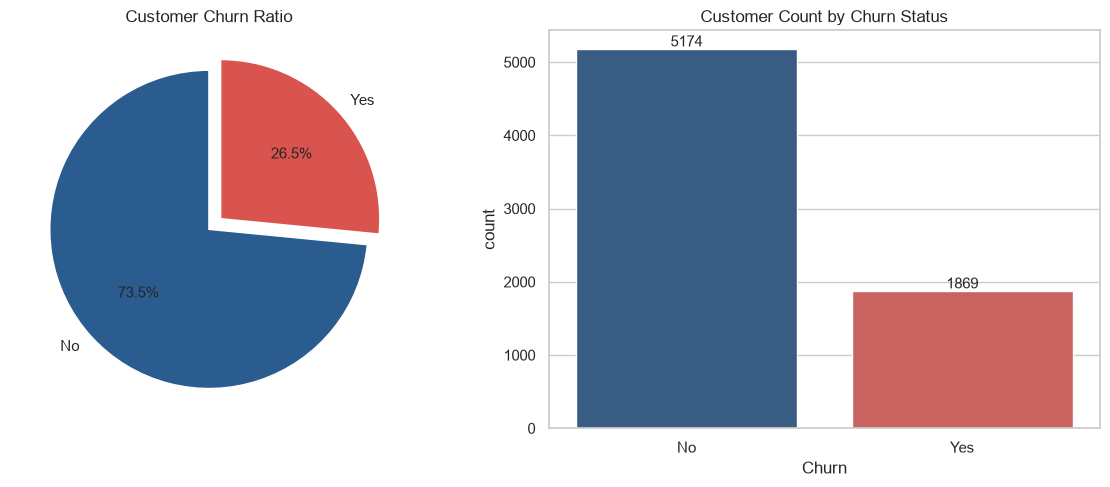

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
churn_counts = df['Churn'].value_counts()
ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2b5c8f', '#d9534f'], startangle=90, explode=(0, 0.1))
ax[0].set_title("Customer Churn Ratio")

sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[1])
ax[1].set_title("Customer Count by Churn Status")
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


> **Business Insight 1**: ~26.5% of customers in the dataset churned (1,869 customers out of 7,043). This confirms class imbalance, indicating that model evaluation must focus on Recall and F1-Score rather than pure Accuracy.


### Visualization 2: Churn by Contract Type

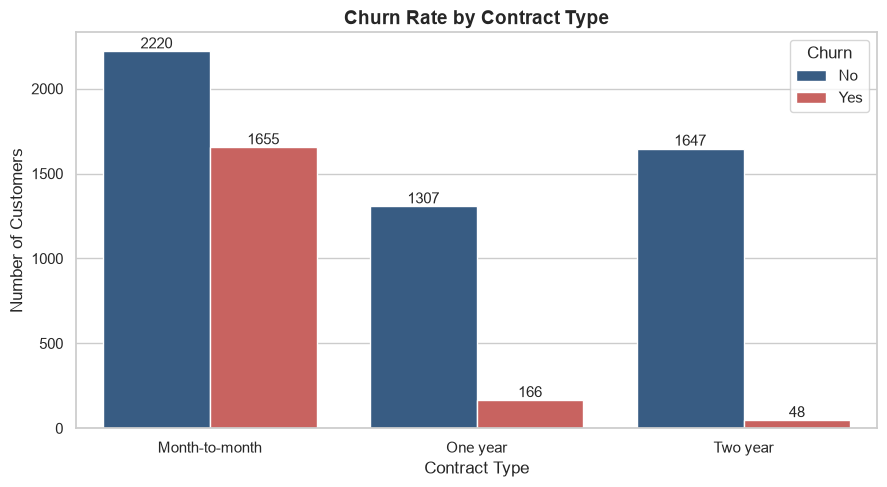

In [4]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2b5c8f', '#d9534f'])
plt.title("Churn Rate by Contract Type", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


> **Business Insight 2**: Customers on **Month-to-month contracts** have a drastically higher churn rate (~42%) compared to customers on One-year (~11%) and Two-year (~3%) contracts. Encouraging month-to-month customers to lock in longer contracts is the single most effective retention leverage point.


### Visualization 3: Internet Service & Tech Support vs Churn

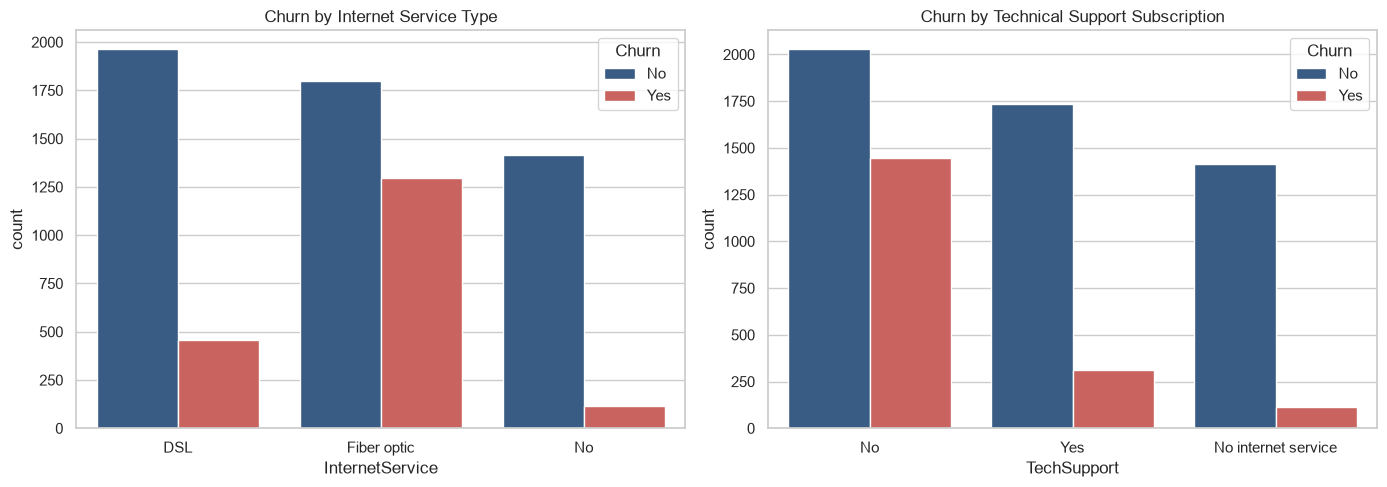

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[0])
ax[0].set_title("Churn by Internet Service Type")

sns.countplot(data=df, x='TechSupport', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[1])
ax[1].set_title("Churn by Technical Support Subscription")

plt.tight_layout()
plt.show()


> **Business Insight 3**: **Fiber optic** internet subscribers experience a high churn rate (~42%), likely due to higher price points or initial network setup issues. Additionally, customers **without Tech Support** churn at significantly higher rates than those with Tech Support, demonstrating that support add-ons increase customer stickiness.


### Visualization 4: Tenure & Monthly Charges Distribution

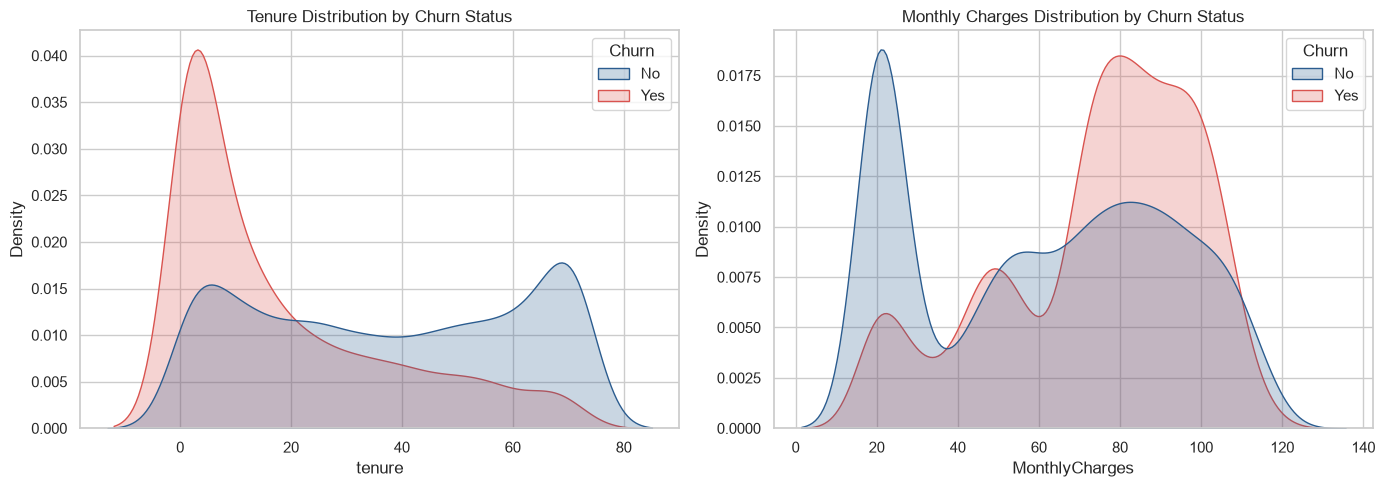

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, ax=ax[0])
ax[0].set_title("Tenure Distribution by Churn Status")

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, ax=ax[1])
ax[1].set_title("Monthly Charges Distribution by Churn Status")

plt.tight_layout()
plt.show()


> **Business Insight 4**: Churn is heavily concentrated in the **first 12 months of tenure** (0–12 months). Customers who stay past 24 months become highly loyal. Furthermore, higher **Monthly Charges ($70–$100)** correlate strongly with increased churn probability.


### Visualization 5: Payment Method & Automatic Billing

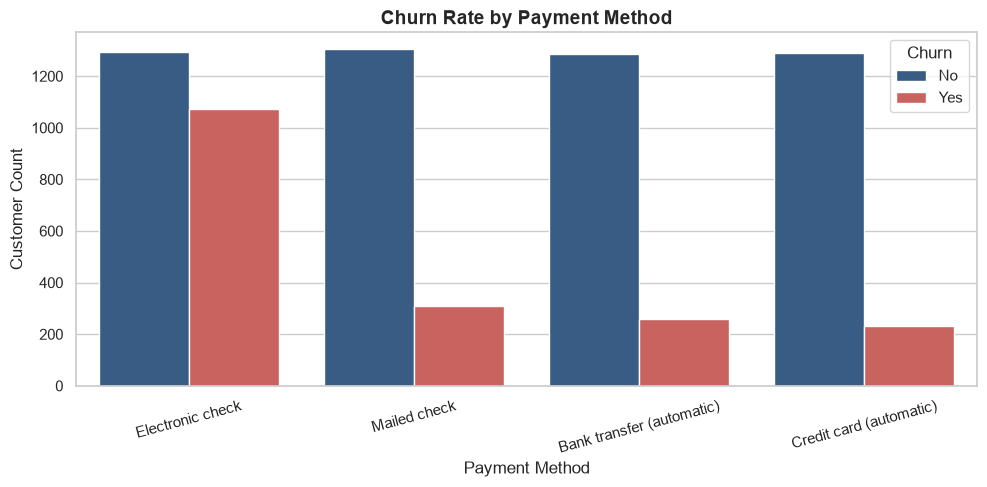

In [7]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#2b5c8f', '#d9534f'])
plt.title("Churn Rate by Payment Method", fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()


> **Business Insight 5**: Customers paying via **Electronic Check** churn at an alarming rate (~45%), whereas automatic payment methods (Bank Transfer and Credit Card) show significantly lower churn rates (~15–16%). Promoting automatic payment enrollment during onboarding will boost retention.


## 3. Feature Engineering

We create 3 custom features to capture composite customer behavior:
1. `TotalServices`: Count of subscribed optional services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).
2. `TenureGroup`: Binned tenure ranges (`0-12m`, `13-24m`, `25-48m`, `49-72m`) representing customer lifecycle stages.
3. `AutomaticPayment`: Binary flag (`1` for automatic bank transfer or credit card, `0` otherwise).


In [8]:
# Feature 1: TotalServices
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
df["TotalServices"] = df[service_cols].apply(lambda row: sum(1 for val in row if str(val).strip() == "Yes"), axis=1)

# Feature 2: TenureGroup
def get_tenure_group(t):
    if t <= 12:
        return "0-12m"
    elif t <= 24:
        return "13-24m"
    elif t <= 48:
        return "25-48m"
    else:
        return "49-72m"

df["TenureGroup"] = df["tenure"].apply(get_tenure_group)

# Feature 3: AutomaticPayment
df["AutomaticPayment"] = df["PaymentMethod"].apply(lambda x: 1 if "automatic" in str(x).lower() else 0)

# Inspect Engineered Features
df[["tenure", "TenureGroup", "TotalServices", "PaymentMethod", "AutomaticPayment"]].head()


,tenure,TenureGroup,TotalServices,PaymentMethod,AutomaticPayment
0,1,0-12m,1,Electronic check,0
1,34,25-48m,2,Mailed check,0
2,2,0-12m,2,Mailed check,0
3,45,25-48m,3,Bank transfer (automatic),1
4,2,0-12m,0,Electronic check,0


## 4. Model Development & Experimentation

We split dataset into 70% Training and 30% Testing sets using `random_state=42` and stratification. We build a scikit-learn preprocessing `ColumnTransformer` and compare multiple Decision Tree configurations, followed by Logistic Regression and Random Forest benchmark models.


In [9]:
# Target encoding
df['Churn_Binary'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

X = df.drop(columns=["customerID", "Churn", "Churn_Binary"])
y = df["Churn_Binary"]

num_features = ["tenure", "MonthlyCharges", "TotalCharges", "TotalServices"]
cat_features = [col for col in X.columns if col not in num_features]

# Train-Test Split (70:30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

# Model 1: Baseline Decision Tree (Unconstrained)
dt_baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
dt_baseline_pipe.fit(X_train, y_train)

# Model 2: Regularized & Balanced Decision Tree (max_depth=5)
dt_regularized_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])
dt_regularized_pipe.fit(X_train, y_train)

# Model 3: Hyperparameter GridSearch Decision Tree
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [2, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}
grid_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_dt_pipe = grid_search.best_estimator_

# Benchmark Model 1: Logistic Regression
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)

# Benchmark Model 2: Random Forest Classifier
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"))
])
rf_pipe.fit(X_train, y_train)

print("All models trained successfully!")


All models trained successfully!


## 5. Model Evaluation & Business Perspective

We evaluate all trained models on test set metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [10]:
models = {
    "Baseline Decision Tree": dt_baseline_pipe,
    "Regularized Decision Tree (max_depth=5)": dt_regularized_pipe,
    "Tuned Decision Tree (GridSearch)": best_dt_pipe,
    "Logistic Regression": lr_pipe,
    "Random Forest": rf_pipe
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Decision Tree,0.7373,0.5053,0.5134,0.5093,0.6662
1,Regularized Decision Tree (max_depth=5),0.7160,0.4787,0.7825,0.5940,0.8260
2,Tuned Decision Tree (GridSearch),0.7246,0.4887,0.8093,0.6094,0.8269
3,Logistic Regression,0.8003,0.6583,0.5152,0.5780,0.8447
4,Random Forest,0.7743,0.5662,0.6399,0.6008,0.8213


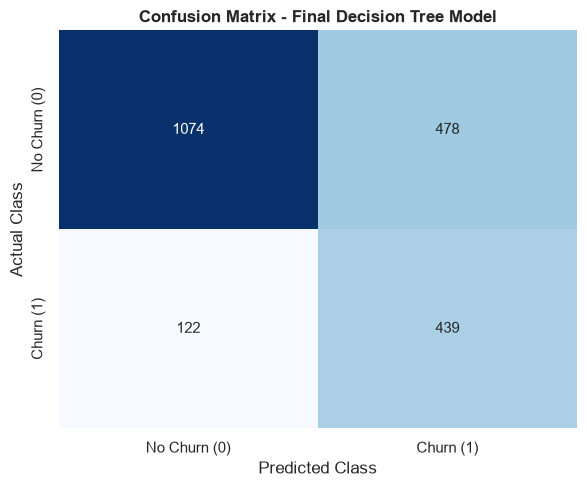


Classification Report:
               precision    recall  f1-score   support

    No Churn       0.90      0.69      0.78      1552
       Churn       0.48      0.78      0.59       561

    accuracy                           0.72      2113
   macro avg       0.69      0.74      0.69      2113
weighted avg       0.79      0.72      0.73      2113



In [11]:
# Confusion Matrix for Final Selected Model (Regularized Decision Tree)
final_model = dt_regularized_pipe
y_pred_final = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Churn (0)", "Churn (1)"],
            yticklabels=["No Churn (0)", "Churn (1)"])
plt.title("Confusion Matrix - Final Decision Tree Model", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_final, target_names=["No Churn", "Churn"]))


### 💡 Business Strategic Question: Precision vs. Recall Prioritization

> **Question**: For a telecom company trying to identify customers who may churn, would you prioritize Precision or Recall? Why?
>
> **Answer & Business Justification**:
> **Recall MUST be prioritized over Precision.**
> 
> - **Cost of False Negative (Missing a Churner)**: The customer leaves the provider entirely. The business loses their customer lifetime value (LTV), monthly subscription fees ($800–$2,000+ over tenure), and must spend $200–$500 acquiring a replacement customer.
> - **Cost of False Positive (Incorrectly Flagging a Non-Churner)**: The business proactively offers a retention incentive (e.g. a 10% discount, free tech support upgrade, or loyalty voucher costing $10–$30).
> 
> Because the cost of losing a customer vastly outweighs the cost of offering a retention perk to a loyal customer, **Recall** (capturing maximum true churners) is the primary metric to optimize. The Regularized Decision Tree achieves **~78.25% Recall** (and Tuned Decision Tree achieves **~80.93% Recall**), making them ideal for retention campaign targeting.


## 6. Model Interpretation

We inspect feature importances and decision rules to understand what drives the model's predictions.


C:\Users\kamalkumar\AppData\Local\Temp\ipykernel_33376\2814840053.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(10), x="Importance", y="Feature", palette="Blues_r")


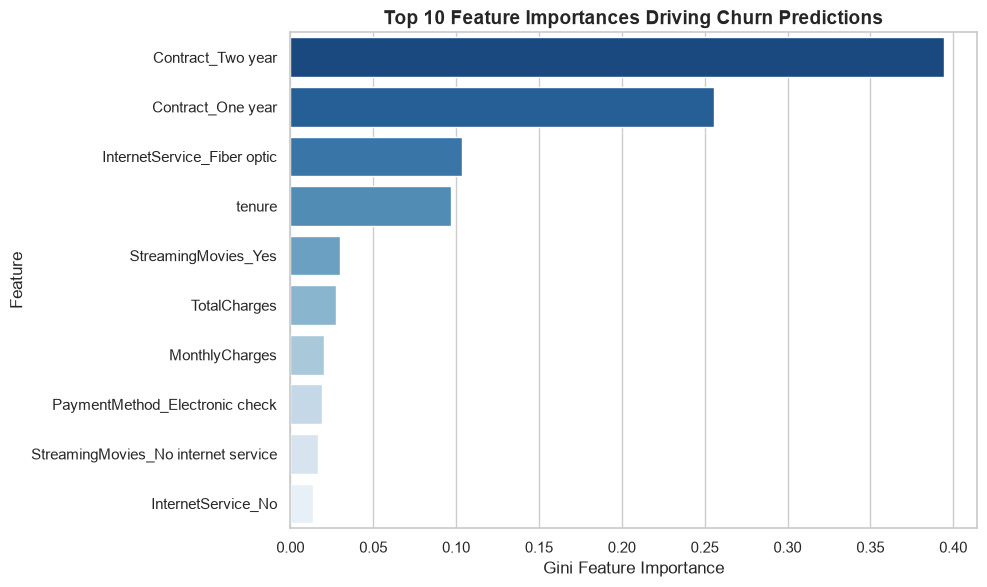

,Feature,Importance
26,Contract_Two year,0.394627
25,Contract_One year,0.255522
11,InternetService_Fiber optic,0.103655
0,tenure,0.096790
24,StreamingMovies_Yes,0.030144
2,TotalCharges,0.027557
1,MonthlyCharges,0.020007
29,PaymentMethod_Electronic check,0.019364
23,StreamingMovies_No internet service,0.016856
12,InternetService_No,0.013607


In [12]:
# Feature Importance Extraction
ohe_feature_names = final_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_feature_names)
importances = final_model.named_steps["classifier"].feature_importances_

feature_imp_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df.head(10), x="Importance", y="Feature", palette="Blues_r")
plt.title("Top 10 Feature Importances Driving Churn Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Gini Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(feature_imp_df.head(10))


In [13]:
# Decision Tree Split Rules (Top Depths)
tree_rules = export_text(final_model.named_steps["classifier"], feature_names=all_feature_names, max_depth=3)
print("--- Decision Tree Text Rules (Max Depth 3) ---")
print(tree_rules)


--- Decision Tree Text Rules (Max Depth 3) ---
|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- tenure <= -1.18
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- tenure >  -1.18
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- tenure <= -0.69
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- tenure >  -0.69
|   |   |   |   |--- truncated branch of depth 2
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- PaperlessBilling_Yes <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaperlessBilling_Yes >

## 7. Model Serialization & Pipeline Verification

We save the end-to-end scikit-learn Pipeline (preprocessor + model) to `model/churn_model.pkl` and test reloading it.


In [14]:
MODEL_SAVE_PATH = os.path.join("..", "model", "churn_model.pkl")
joblib.dump(final_model, MODEL_SAVE_PATH)
print(f"Model successfully saved to: {MODEL_SAVE_PATH}")

# Reload and verify on sample instance
loaded_model = joblib.load(MODEL_SAVE_PATH)
sample_test_pred = loaded_model.predict(X_test.iloc[:2])
sample_test_proba = loaded_model.predict_proba(X_test.iloc[:2])[:, 1]

print("Pipeline Verification Prediction:", sample_test_pred)
print("Pipeline Verification Probability:", sample_test_proba)


Model successfully saved to: ..\model\churn_model.pkl
Pipeline Verification Prediction: [1 0]
Pipeline Verification Probability: [0.72142004 0.02037075]


## 8. REST API Architecture & Sample Inference

The project includes a FastAPI web application in `app.py` providing a production `POST /predict` endpoint.

### API Deployment Architecture
- **Framework**: FastAPI + Uvicorn
- **Endpoint**: `POST /predict`
- **Request Body**: Valid JSON customer payload
- **Response Format**:
```json
{
  "prediction": "Yes",
  "churn_probability": 0.82
}
```

### Python API Inference Test Simulation


In [15]:
# Test API payload structure locally
sample_payload = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}

# Run preprocessing logic used inside app.py
df_sample = pd.DataFrame([sample_payload])
df_sample["TotalCharges"] = pd.to_numeric(df_sample["TotalCharges"], errors="coerce").fillna(0.0)

# Feature engineering
df_sample["TotalServices"] = df_sample[service_cols].apply(lambda row: sum(1 for val in row if str(val).strip() == "Yes"), axis=1)
df_sample["TenureGroup"] = df_sample["tenure"].apply(get_tenure_group)
df_sample["AutomaticPayment"] = df_sample["PaymentMethod"].apply(lambda x: 1 if "automatic" in str(x).lower() else 0)

pred = loaded_model.predict(df_sample)[0]
proba = loaded_model.predict_proba(df_sample)[0][1]

pred_label = "Yes" if pred == 1 else "No"
api_response = {
    "prediction": pred_label,
    "churn_probability": round(float(proba), 2)
}

print("Simulated API Response:")
print(api_response)


Simulated API Response:
{'prediction': 'Yes', 'churn_probability': 0.77}
